# 实验报告3：目标检测与分割部署
## 一、实验目的
1. 理解定位与回归逻辑：掌握边界框（Bounding Box）的表示方法及 IoU 损失函数的数学原理； 
2. 掌握工业级推理流程：学习使用 CPU 环境进行 YOLO 系列模型的推理与性能分析； 
3. 强化模型部署与端侧优化能力：学习 ONNX 格式转换与推理后端优化，理解工业界从训练到部署的全链路。 


## 二、实验环境与数据说明表

| 项目         | 填写内容                                      |
| ------------ | --------------------------------------------- |
| 运行设备     | 个人电脑                                      |
| 硬件环境     | GPU                                           |
| 软件环境     | torch2.12.0+cu126                             |
| 数据集       | MNIST                                         |
| 训练集数量   | 60000                                         |
| 测试集数量   | 10000                                         |
| 数据预处理   | transforms.Normalize((0.1307,), (0.3081,)) |
| ……           | ……                                            |

## 三、实验原理

### 1. 目标检测核心：回归与 NMS

* **边界框回归**：
  目标检测不仅需要识别图像中物体的类别（分类任务），还需要精确预测其空间位置（回归任务）。
  - **坐标表示**：边界框通常表示为 $(x, y, w, h)$（中心点坐标与宽高）或 $(x_{min}, y_{min}, x_{max}, y_{max})$（左上角与右下角坐标）。由于直接回归绝对坐标对图像尺度极其敏感，现代检测器（如 YOLO系列、Faster R-CNN）通常预测边界框相对于预设锚框的**偏移量**。
  - **损失函数演进**：早期常使用均方误差（MSE）回归坐标，但 MSE 假设坐标变量间相互独立，且无法直接反映框的重合程度。因此，现代算法广泛采用 **IoU Loss** 及其变体（如 **GIoU、DIoU、CIoU**）。这些变体不仅考虑了重叠面积，还引入了中心点距离、长宽比等几何约束，解决了无重叠时梯度为零导致的训练收敛缓慢问题，显著提升了定位精度。
  - **IoU（交并比）**：作为评价指标，IoU 计算预测框 $A$ 与真值框 $B$ 的交集面积与并集面积之比，即 $IoU = \frac{|A \cap B|}{|A \cup B|}$，直观衡量了定位的准确度。

* **NMS（非极大值抑制）**：
  在推理阶段，由于滑动窗口或密集锚点机制，模型常会在同一物体上产生大量高得分的重叠候选框。NMS 是后处理中不可或缺的去重步骤。
  - **标准 NMS 流程**：
    1. 将所有候选框按置信度得分降序排列；
    2. 取得分最高的框作为基准框，将其加入最终输出列表；
    3. 计算剩余框与基准框的 IoU，剔除 IoU 大于预设阈值（如 0.5）的框；
    4. 重复步骤 2-3，直到所有框均被处理。
  - **痛点与改进**：标准 NMS 的主要缺陷是**遮挡漏检**——当两个不同物体高度重叠时，得分稍低的物体会被错误剔除。为此衍生出 **Soft-NMS**（不直接剔除，而是按 IoU 大小衰减重叠框的得分）和 **DIoU-NMS**（将中心点距离纳入剔除考量）等改进方案。

### 2. U-Net 与语义分割

* **编码器-解码器架构**：
  语义分割是像素级的分类任务，要求输出与输入图像分辨率完全相同的掩码。U-Net 采用经典的对称结构：**编码器**通过连续的卷积和下采样（如最大池化）提取特征，感受野逐渐扩大，获取高层语义信息；**解码器**通过上采样（如转置卷积或双线性插值）逐步恢复空间分辨率，实现从“理解是什么”到“确定在哪里”的转变。

* **跳跃连接**：
  这是 U-Net 的核心创新。在下采样过程中，虽然高层语义不断增强，但空间细节（如边缘、精确位置）不可避免地严重丢失。
  - **融合机制**：U-Net 将编码器中对应层的高分辨率特征图，直接**拼接**到解码器上采样后的特征图上。这使得解码器在恢复分辨率时，既能拥有深层的语义判别力，又能获得浅层的空间定位能力，有效缓解了因池化导致的信息不可逆丢失。
  - **特征对齐**：由于编码器特征图经历了卷积操作，其空间尺寸可能与解码器特征图存在微小差异，拼接前通常需要对编码器特征进行中心裁剪以严格对齐。

* **上采样策略**：
  解码器恢复分辨率的方式直接影响分割的精细度。**双线性插值**无需学习参数，计算量小；**转置卷积**（Transposed Convolution）则通过可学习的权重自适应地调整上采样权重，能更好地恢复细节，但若参数设置不当易产生棋盘格伪影。U-Net 常结合两者优势进行设计。


## 四、实验过程与关键代码
### 阶段一：目标检测
#### 1. 极简数字定位训练（自建模型）
任务要求：编写脚本随机生成 64×64 的黑底画布，并在随机位置贴上一个 MNIST 数字。搭建一个轻量级 CNN 回归器，输出由10维扩展成 10（类）+4 维向量 $x,y,w,ℎ$。编写 **IoU（交并比）计算函数**，并将其作为评估指标。尝试使用 CIoU 或 DIoU 代替简单的 MSE 损失，观察收敛速度的变化。 



编写 Python 脚本，利用 torchvision.datasets.MNIST 的数据随机贴图，并记录其坐标作为真值。 


In [1]:
# 环境配置与导入
%matplotlib inline
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
from torch.optim import lr_scheduler
import copy
import numpy as np
from torch.utils.data import Dataset
import time

print("环境配置完成")
print(torch.cuda.is_available())

环境配置完成
True


In [2]:
# 数据路径和超参数设置
data_root = './mnist_data/' # 尽量避免中文路径
batch_size = 64

 # 创建数据目录（如果不存在）
if not os.path.exists(data_root):
    os.makedirs(data_root)

print(f"数据存储路径: {data_root}")
print(f"批量大小: {batch_size}")

数据存储路径: ./mnist_data/
批量大小: 64


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 使用 DataLoader 分批次加载数据集
train_dataset = datasets.MNIST(root=data_root, train=True, 
                               download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, 
                              download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # 打乱样本顺序，提高训练效果
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(" MNIST 数据集加载完成")
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

 MNIST 数据集加载完成
训练集大小: 60000
测试集大小: 10000


In [ ]:
# 自建随机贴图数据集
class CanvasMNISTDataset(Dataset):
    def __init__(self, mnist_dataset, canvas_size=64):
        self.mnist = mnist_dataset
        self.canvas_size = canvas_size

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):  # 在getiem的时候随机放置，每次获取的结果都不一样
        img, label = self.mnist[idx]
        # img shape: [1, 28, 28]
        
        # 随机选择左上角坐标，确保数字不超出画布
        max_pos = self.canvas_size - 28
        x1 = np.random.randint(0, max_pos)
        y1 = np.random.randint(0, max_pos)
        x2 = x1 + 28
        y2 = y1 + 28
        
        # 创建画布并贴图
        canvas = torch.zeros((1, self.canvas_size, self.canvas_size))
        canvas[:, y1:y2, x1:x2] = img
        
        # 归一化或绝对坐标 bbox: [x_center, y_center, w, h] 归一化形式
        cx = (x1 + x2) / 2.0 / self.canvas_size
        cy = (y1 + y2) / 2.0 / self.canvas_size
        w = 28.0 / self.canvas_size
        h = 28.0 / self.canvas_size
        
        bbox = torch.tensor([cx, cy, w, h], dtype=torch.float32)
        
        return canvas, label, bbox

# 实例化新的 DataLoader
train_canvas_set = CanvasMNISTDataset(train_dataset)
test_canvas_set = CanvasMNISTDataset(test_dataset)

train_canvas_loader = DataLoader(train_canvas_set, batch_size=64, shuffle=True)
test_canvas_loader = DataLoader(test_canvas_set, batch_size=64, shuffle=False)


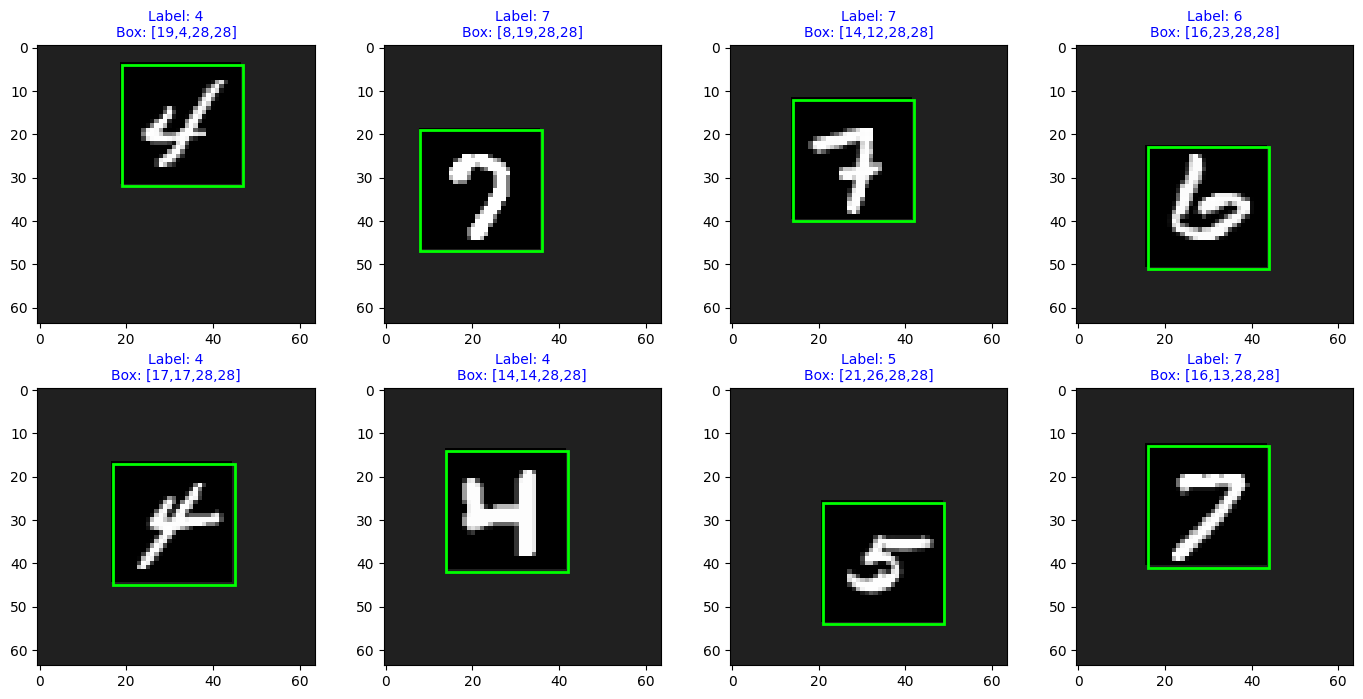

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize_canvas_mnist(dataset, num_samples=4):
    """
    可视化 CanvasMNISTDataset 的生成结果，自动将归一化的 [cx, cy, w, h] 还原并绘制边界框。
    
    参数:
    - dataset: 实例化后的 CanvasMNISTDataset 对象
    - num_samples: 想要查看的样本数量（建议为 4 的倍数）
    """
    # 计算网格的行数和列数
    cols = 4
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    canvas_size = dataset.canvas_size
    
    for i in range(num_samples):
        # 随机抽取一个样本
        idx = np.random.randint(0, len(dataset))
        canvas, label, bbox = dataset[idx]
        
        # 将 Tensor 转回 numpy 图像格式 [H, W]
        img_data = canvas.squeeze().numpy()
        
        # 解析归一化的 [cx, cy, w, h] 并还原到像素坐标
        cx, cy, w, h = bbox.numpy()
        cx_px = cx * canvas_size
        cy_px = cy * canvas_size
        w_px = w * canvas_size
        h_px = h * canvas_size
        
        # 从中心点坐标 (cx, cy) 换算回左上角坐标 (x1, y1) 用于 matplotlib 绘图
        x1_px = cx_px - w_px / 2.0
        y1_px = cy_px - h_px / 2.0
        
        # 绘图
        ax = axes[i]
        ax.imshow(img_data, cmap='gray')
        
        # 创建边界框（Edgecolor='lime' 绿色荧光框，更加醒目）
        rect = patches.Rectangle(
            (x1_px, y1_px), w_px, h_px, 
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        
        # 标注类别和坐标提示
        ax.set_title(f"Label: {label}\nBox: [{x1_px:.0f},{y1_px:.0f},28,28]", fontsize=10, color='blue')
        ax.axis('on') # 开启坐标轴可以更清晰地肉眼比对位置
        
    # 关闭多余的子图
    for j in range(num_samples, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()
visualize_canvas_mnist(train_canvas_set, num_samples=8)

In [42]:
# 计算 IOU 和 DIoU
def bbox_iou_and_diou(pred, target):
    """
    pred, target: [B, 4] 格式为 [cx, cy, w, h] (归一化坐标)
    """
    # 转为左上角和右下角
    b1_x1, b1_x2 = pred[:, 0] - pred[:, 2] / 2, pred[:, 0] + pred[:, 2] / 2
    b1_y1, b1_y2 = pred[:, 1] - pred[:, 3] / 2, pred[:, 1] + pred[:, 3] / 2
    b2_x1, b2_x2 = target[:, 0] - target[:, 2] / 2, target[:, 0] + target[:, 2] / 2
    b2_y1, b2_y2 = target[:, 1] - target[:, 3] / 2, target[:, 1] + target[:, 3] / 2

    # 交集
    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)
    
    inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)
    
    # 并集
    b1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    b2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)
    union_area = b1_area + b2_area - inter_area + 1e-7
    
    iou = inter_area / union_area
    
    # DIoU 项：计算最小外接矩形和中心点距离
    cw_x1 = torch.min(b1_x1, b2_x1)
    cw_y1 = torch.min(b1_y1, b2_y1)
    cw_x2 = torch.max(b1_x2, b2_x2)
    cw_y2 = torch.max(b1_y2, b2_y2)
    
    # 最小外接矩形对角线距离的平方
    c2 = (cw_x2 - cw_x1) ** 2 + (cw_y2 - cw_y1) ** 2 + 1e-7
    
    # 中心点距离的平方
    rho2 = (pred[:, 0] - target[:, 0]) ** 2 + (pred[:, 1] - target[:, 1]) ** 2
    
    diou = iou - rho2 / c2
    return iou, 1.0 - diou

In [ ]:
# 搭建回归网络
class DigitDetector(nn.Module):
    def __init__(self):
        super(DigitDetector, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), # 64x64
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 32x32
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 8x8
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 14) # 10 cls + 4 bbox
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        out = self.fc(x)
        cls_out = out[:, :10]
        bbox_out = torch.sigmoid(out[:, 10:]) # 限制在 [0, 1] 范围内
        return cls_out, bbox_out

In [49]:
# 训练
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DigitDetector().to(device)
def train(model, train_loader, device, epochs=10, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    cls_criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs): 
        model.train()
        total_loss, total_iou, correct = 0, 0, 0
        correct = 0
        for imgs, labels, bboxes in train_loader:
            imgs, labels, bboxes = imgs.to(device), labels.to(device), bboxes.to(device)
            
            optimizer.zero_grad()
            cls_pred, bbox_pred = model(imgs)
            loss_cls = cls_criterion(cls_pred, labels)
            iou_val, loss_diou = bbox_iou_and_diou(bbox_pred, bboxes)
            
            loss = loss_cls + loss_diou.mean() * 2.0 # 适当加大回归权重
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_iou += iou_val.mean().item()
            
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Mean IoU: {total_iou/len(train_loader):.4f}")

train(model, train_canvas_loader, device, epochs=20)


Epoch 1, Loss: 1.2663, Mean IoU: 0.9202
Epoch 2, Loss: 0.2710, Mean IoU: 0.9472
Epoch 3, Loss: 0.1894, Mean IoU: 0.9592
Epoch 4, Loss: 0.1571, Mean IoU: 0.9637
Epoch 5, Loss: 0.1371, Mean IoU: 0.9682
Epoch 6, Loss: 0.1225, Mean IoU: 0.9705
Epoch 7, Loss: 0.1127, Mean IoU: 0.9716
Epoch 8, Loss: 0.1072, Mean IoU: 0.9742
Epoch 9, Loss: 0.0988, Mean IoU: 0.9745
Epoch 10, Loss: 0.0929, Mean IoU: 0.9764
Epoch 11, Loss: 0.0908, Mean IoU: 0.9766
Epoch 12, Loss: 0.0869, Mean IoU: 0.9781
Epoch 13, Loss: 0.0832, Mean IoU: 0.9786
Epoch 14, Loss: 0.0793, Mean IoU: 0.9795
Epoch 15, Loss: 0.0765, Mean IoU: 0.9806
Epoch 16, Loss: 0.0750, Mean IoU: 0.9808
Epoch 17, Loss: 0.0730, Mean IoU: 0.9814
Epoch 18, Loss: 0.0681, Mean IoU: 0.9816
Epoch 19, Loss: 0.0671, Mean IoU: 0.9824
Epoch 20, Loss: 0.0680, Mean IoU: 0.9824


Cls Loss:  0.0316
BBox Loss: 0.0182
Accuracy:    98.99%
Mean IoU: 0.9818


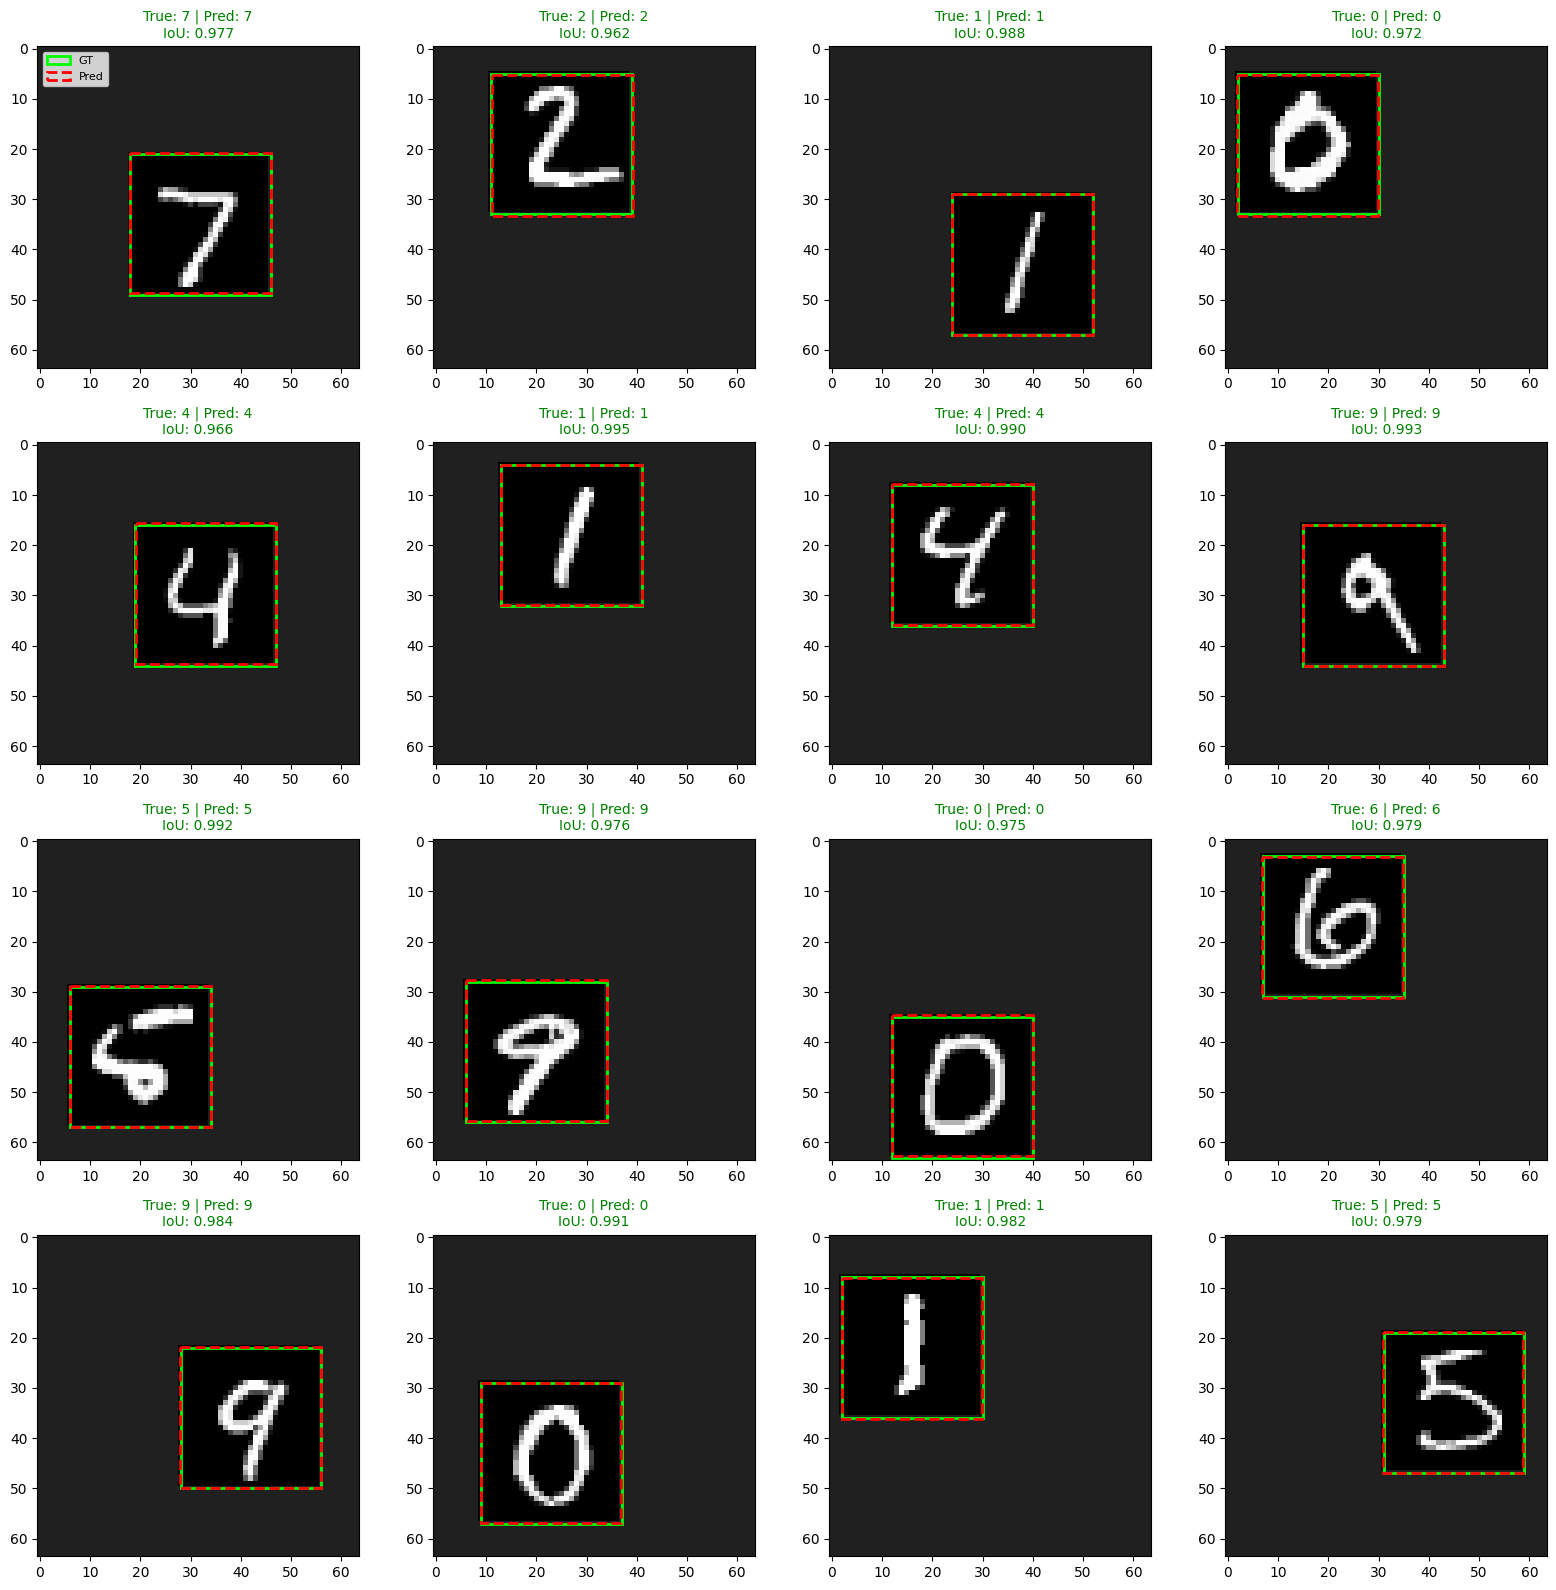

In [50]:
# 测试模型
@torch.no_grad
def evaluate_and_visualize(model, data_loader, device, num_visualize=4):
    """
    对检测模型进行全面评估，输出 Loss、Accuracy、Mean IoU，并可视化预测结果。
    
    参数:
    - model: 训练好的 DigitDetector 模型
    - data_loader: 测试集的 DataLoader (test_canvas_loader)
    - device: torch.device ('cuda' 或 'cpu')
    - num_visualize: 抽样可视化的图片数量（建议为 4）
    """
    model.eval() # 切换为评估模式
    
    total_cls_loss = 0.0
    total_bbox_loss = 0.0
    correct_cls = 0
    total_samples = 0
    total_iou = 0.0
    
    cls_criterion = torch.nn.CrossEntropyLoss()
    
    # 用于存储一组数据专门用来可视化的变量
    vis_imgs, vis_labels, vis_bboxes, vis_pred_cls, vis_pred_bboxes = None, None, None, None, None
    
    with torch.no_grad(): # 验证阶段不计算梯度
        for batch_idx, (imgs, labels, bboxes) in enumerate(data_loader):
            imgs, labels, bboxes = imgs.to(device), labels.to(device), bboxes.to(device)
            
            # 模型前向传播
            cls_pred, bbox_pred = model(imgs)
            
            # 计算分类 Loss 与准确率
            loss_cls = cls_criterion(cls_pred, labels)
            total_cls_loss += loss_cls.item() * imgs.size(0)
            
            _, predicted = torch.max(cls_pred, 1)
            correct_cls += (predicted == labels).sum().item()
            
            # 计算回归 IoU 与 Loss
            iou_val, loss_diou = bbox_iou_and_diou(bbox_pred, bboxes)
            total_bbox_loss += loss_diou.mean().item() * imgs.size(0)
            total_iou += iou_val.sum().item()
            
            total_samples += imgs.size(0)
            
            # 顺便保存第一个 batch 的前几张图用于后续可视化展示
            if batch_idx == 0:
                vis_imgs = imgs[:num_visualize].cpu()
                vis_labels = labels[:num_visualize].cpu()
                vis_bboxes = bboxes[:num_visualize].cpu()
                vis_pred_cls = predicted[:num_visualize].cpu()
                vis_pred_bboxes = bbox_pred[:num_visualize].cpu()

    # ---- 1. 计算并打印统计指标 ----
    avg_cls_loss = total_cls_loss / total_samples
    avg_bbox_loss = total_bbox_loss / total_samples
    accuracy = (correct_cls / total_samples) * 100.0
    mean_iou = total_iou / total_samples
    
    print(f"Cls Loss:  {avg_cls_loss:.4f}")
    print(f"BBox Loss: {avg_bbox_loss:.4f}")
    print(f"Accuracy:    {accuracy:.2f}%")
    print(f"Mean IoU: {mean_iou:.4f}")
    
    # ---- 2. 绘制可视化样例 ----
    canvas_size = data_loader.dataset.canvas_size
    cols = 4
    rows = (num_visualize + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten() if num_visualize > 1 else [axes]
    
    for i in range(num_visualize):
        img_data = vis_imgs[i].squeeze().numpy()
        ax = axes[i]
        ax.imshow(img_data, cmap='gray')
        
        # A. 解析并绘制真实框 (Ground Truth) -> 绿色
        gt_cx, gt_cy, gt_w, gt_h = vis_bboxes[i].numpy()
        gt_x1 = (gt_cx - gt_w / 2.0) * canvas_size
        gt_y1 = (gt_cy - gt_h / 2.0) * canvas_size
        rect_gt = patches.Rectangle(
            (gt_x1, gt_y1), gt_w * canvas_size, gt_h * canvas_size, 
            linewidth=2, edgecolor='lime', facecolor='none', label='GT'
        )
        ax.add_patch(rect_gt)
        
        # B. 解析并绘制预测框 (Prediction) -> 红色
        p_cx, p_cy, p_w, p_h = vis_pred_bboxes[i].numpy()
        p_x1 = (p_cx - p_w / 2.0) * canvas_size
        p_y1 = (p_cy - p_h / 2.0) * canvas_size
        rect_pred = patches.Rectangle(
            (p_x1, p_y1), p_w * canvas_size, p_h * canvas_size, 
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='Pred'
        )
        ax.add_patch(rect_pred)
        
        # 计算单张图的 IoU 用于标题展示
        # 这里单独转成 batch 形式调一下你之前的 iou 函数
        single_iou, _ = bbox_iou_and_diou(vis_pred_bboxes[i].unsqueeze(0), vis_bboxes[i].unsqueeze(0))
        
        # 设置标题：展示真实标签、预测标签以及当前框的 IoU
        title_color = 'green' if vis_pred_cls[i] == vis_labels[i] else 'red'
        ax.set_title(
            f"True: {vis_labels[i]} | Pred: {vis_pred_cls[i]}\nIoU: {single_iou.item():.3f}", 
            color=title_color, fontsize=10
        )
        ax.axis('on')
        if i == 0:
            ax.legend(loc='upper left', fontsize=8) # 仅在第一张图加上图例防乱
            
    for j in range(num_visualize, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()
evaluate_and_visualize(model, test_canvas_loader, device, num_visualize=16)

#### 2. YOLOv8 推理实践（模型工程）
任务要求：加载预训练的 yolov8n.pt 权重（极轻量，适配 CPU）。在 CPU 上对宿舍生活照片或实验室场景进行推理。手动实现 **NMS（非极大值抑制）** 算法逻辑，对比不同置信度阈值对模型检测结果（准确率与召回率）的影响。 


实现非极大值抑制（NMS）

In [30]:
import cv2
import numpy as np
import torch
from ultralytics import YOLO

def manual_nms(bboxes, scores, iou_threshold=0.45):
    """
    bboxes: [N, 4] 格式为 [x1, y1, x2, y2]
    scores: [N] 对应置信度得分
    """
    x1 = bboxes[:, 0]
    y1 = bboxes[:, 1]
    x2 = bboxes[:, 2]
    y2 = bboxes[:, 3]
    
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort(descending=True)

    keep = []
    while order.numel() > 0:
        if order.numel() == 1:
            keep.append(order.item())
            break
        i = order[0].item()
        keep.append(i)
        
        # 计算当前最高得分框与其余框的交集坐标
        xx1 = torch.clamp(x1[order[1:]], min=x1[i])
        yy1 = torch.clamp(y1[order[1:]], min=y1[i])
        xx2 = torch.clamp(x2[order[1:]], max=x2[i])
        yy2 = torch.clamp(y2[order[1:]], max=y2[i])
        
        w = torch.clamp(xx2 - xx1, min=0.0)
        h = torch.clamp(yy2 - yy1, min=0.0)
        inter = w * h
        
        # 计算 IoU
        ovr = inter / (areas[i] + areas[order[1:]] - inter + 1e-7)
        
        # 保留 IoU 小于阈值的框
        inds = torch.where(ovr <= iou_threshold)[0]
        order = order[inds + 1] # 因为 ovr 索引错开了一位    
    return keep

使用 NMS

原始冗余边界框数量: 46
NMS 后边界框数量: 24
tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0., 62., 39.,  9., 56., 25., 28., 73., 56., 73., 25., 62.,  0.,  0.,  0., 56., 73.,  0.])
[0, 2, 3, 4, 6, 7, 8, 11, 13, 14, 16, 17, 23, 25, 27, 28, 31, 32, 34, 36, 38, 41, 42, 45]
原始冗余边界框数量: 12
NMS 后边界框数量: 8
tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0., 62.])
[0, 2, 3, 4, 6, 7, 8, 11]
原始冗余边界框数量: 7
NMS 后边界框数量: 5
tensor([0., 0., 0., 0., 0.])
[0, 2, 3, 4, 6]


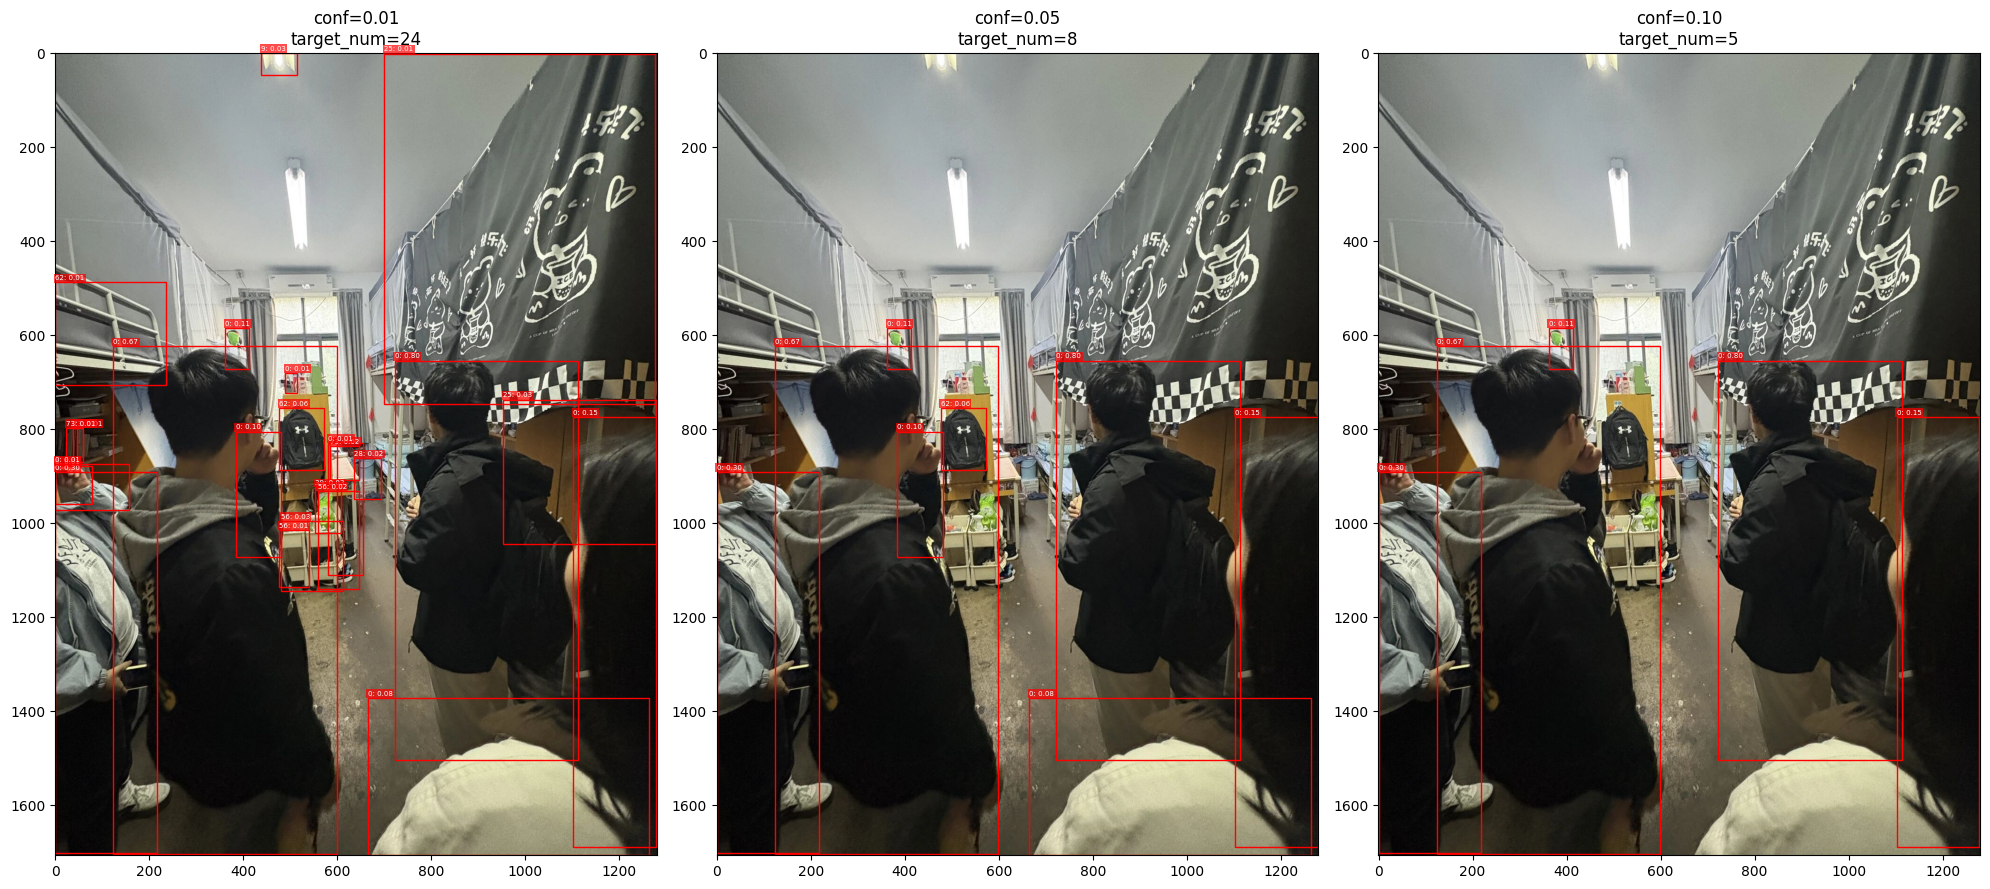

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
yolo_model = YOLO("yolov8n.pt")
img_path = 'room.jpeg'

conf_thresholds = [0.01, 0.05, 0.1]

fig, axes = plt.subplots(1, len(conf_thresholds), figsize=(20, 15))

for conf_index, conf in enumerate(conf_thresholds):
    results = yolo_model.predict(source=img_path, device='cpu', conf=conf,
                                 verbose=False)[0]

    raw_boxes = results.boxes.xyxy  # [N, 4] 格式为 [x1, y1, x2, y2]
    raw_scores = results.boxes.conf  # [N] 每个框的最大类别置信度
    raw_labels = results.boxes.cls   # [N] 对应的类别索引

    print(f"原始冗余边界框数量: {len(raw_boxes)}")
    keep_order = manual_nms(raw_boxes, raw_scores)
    print(f"NMS 后边界框数量: {len(keep_order)}")
    img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)

    keep_bboxes = raw_boxes[keep_order]
    keep_scores = raw_scores[keep_order]
    keep_labels = raw_labels[keep_order]
    print(keep_labels)

    print(keep_order)
    # 可视化
    axes[conf_index].imshow(img)
    for i, bbox in enumerate(keep_bboxes):
        rect = plt.Rectangle((int(bbox[0]), int(bbox[1])), int(bbox[2] - bbox[0]), int(bbox[3] - bbox[1]),
                            edgecolor='red',
                            linewidth=1,
                            fill=False)
        axes[conf_index].add_patch(rect)
        axes[conf_index].text(int(bbox[0]), int(bbox[1]) - 5,
                f"{keep_labels[i]:.0f}: {keep_scores[i]:.2f}",
                color='white', fontsize=5,
                bbox=dict(
                    facecolor='red',    # 背景色
                    alpha=0.7,          # 透明度
                    edgecolor='none',   # 无边框
                    pad=1               # 内边距
                ))
        
    axes[conf_index].set_title(f"conf={conf:.2f}\ntarget_num={len(keep_order)}")


plt.tight_layout()
plt.show()

0: person，
9: traffic light，
39: bottle，
56: chair，
62: tv，
73: book

conf=0.01 除了人部分识别正确外，其他都对应错了。

conf=0.05 把玩偶和手臂识别成了人，把书包识别成了电视，把未完全进入镜头的人识别成了两个人。

conf=0.10 虽然再次把玩偶识别为了人，但结果较为正确，四个人都识别出来了。

### 阶段二：语义分割与推理后端优化
#### 1. Tiny U-Net 像素级分割训练
任务要求：搭建带有跳跃连接（Skip Connection）的轻量化 U-Net 结构。对合成的数字拼图进行掩码分割，区分“前景（数字线条）”与黑底“背景”。 


使用 nn.Module 实现简单的回归网络和 Tiny U-Net。
摘自[TinyU-Net](https://github.com/ChenJunren-Lab/TinyU-Net)
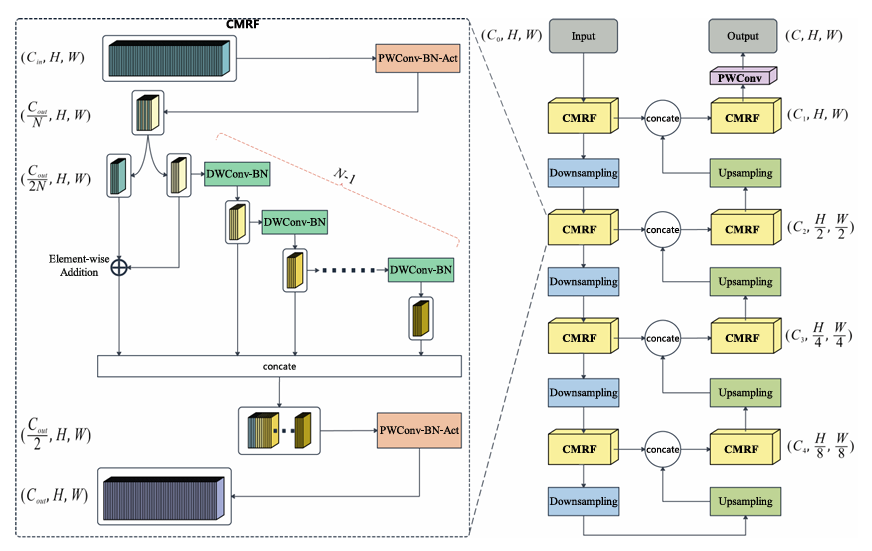

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from thop import clever_format, profile
from torchsummary import summary

def autopad(k, p=None, d=1):  
    '''
    k: kernel
    p: padding
    d: dilation
    '''
    if d > 1:
        # actual kernel-size
        k = d * (k - 1) + 1 if isinstance(k, int) else [d * (x - 1) + 1 for x in k] # actual kernel-size
        # 如果 k 是列表就批量操作
    if p is None:
        # auto-pad
        p = k // 2 if isinstance(k, int) else [x // 2 for x in k] # auto-pad
    return p


class Conv(nn.Module):
    """Standard convolution with args(ch_in, ch_out, kernel, stride, paddin g, groups, dilation, activation)."""
    default_act = nn.GELU()
    def __init__(self, c1, c2, k=1, s=1, p=None, g=1, d=1, act=True):
        super().__init__()
        self.conv   = nn.Conv2d(c1, c2, k, s, autopad(k, p, d), groups=g, dilation=d, bias=False)
        self.bn     = nn.BatchNorm2d(c2, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        self.act    = self.default_act if act is True else act if isinstance(act, nn.Module) else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

    def forward_fuse(self, x):
        return self.act(self.conv(x))


class DWConv(Conv):
    """Depth-wise convolution with args(ch_in, ch_out, kernel, stride, dilation, activation)."""
    def __init__(self, c1, c2, k=1, s=1, d=1, act=True):
        super().__init__(c1, c2, k, s, g=math.gcd(c1, c2), d=d, act=act)

    
# Lightweight Cascade Multi-Receptive Fields Module
class CMRF(nn.Module):
    """CMRF Module with args(ch_in, ch_out, number, shortcut, groups, expansion)."""
    def __init__(self, c1, c2, N=8, shortcut=True, g=1, e=0.5):
        super().__init__()
        # 必须让 c2 // self.N 为偶数
        
        self.N         = N
        self.c         = int(c2 * e / self.N)  # c2//self.N/2
        self.add       = shortcut and c1 == c2  # 是否使用 shortcut connection
        
        self.pwconv1   = Conv(c1, c2//self.N, 1, 1)  # 输入 c1，输出 c2//self.N
        self.pwconv2   = Conv(c2//2, c2, 1, 1)      # 输入 c2//2，输出 c2
        self.m         = nn.ModuleList(DWConv(self.c, self.c, k=3, act=False) for _ in range(N-1))

    def forward(self, x):
        """Forward pass through CMRF Module."""
        x_residual = x  # 残差
        x          = self.pwconv1(x)  # (B, c1, H, W) → (B, c2//self.N, H, W)

        x          = [x[:, 0::2, :, :], x[:, 1::2, :, :]]  # 按通道奇偶拆分
        # (B, c2//self.N, H, W) -> [(B, c2//self.N/2, H, W), (B, c2//self.N/2, H, W)]
        
        x.extend(m(x[-1]) for m in self.m)
        # [even_part, odd_part, conv0(odd_part), conv1(conv0(odd_part)), ...]
        # DWConv不改变通道数，self.c = c2//self.N/2
        
        x[0]       = x[0] +  x[1] # 如果 c2 // self.N 不为偶数，因为通道数不同，会报错
        # 奇偶分量合并
        
        x.pop(1)  # 将 奇分量 移除
        
        y          = torch.cat(x, dim=1) # 总通道数 = (c2//self.N)/2 + (N-1)*c2//self.N/2  = c2//2
        # c2 = 17 c2//8 = 2，同时 c2 // N * N / 2 = 2 * 8 / 2 = 8，即 c2//2
        y          = self.pwconv2(y) # (B, c2//2, H, W) → (B, c2, H, W)
        return x_residual + y if self.add else y  # 执行残差连接的前提条件是 c1 == c2
'''
U-shape/U-like Model
'''
# Encoder in TinyU-Net
class UNetEncoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNetEncoder, self).__init__()
        self.cmrf       = CMRF(in_channels, out_channels)
        self.downsample = nn.MaxPool2d(kernel_size=2, stride=2)
        
    def forward(self, x):
        x = self.cmrf(x)
        return self.downsample(x), x  # 
    

# Decoder in TinyU-Net
class UNetDecoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNetDecoder, self).__init__()
        self.cmrf      = CMRF(in_channels, out_channels)
        self.upsample  = F.interpolate
        
    def forward(self, x, skip_connection):
        x = self.upsample(x, scale_factor=2, mode='bicubic', align_corners=False)
        x = torch.cat([x, skip_connection], dim=1)  # 通道数合并
        x = self.cmrf(x)
        return x
    

# TinyU-Net
class TinyUNet(nn.Module):
    """TinyU-Net with args(in_channels, num_classes)."""
    '''
    in_channels: The number of input channels
    num_classes: The number of segmentation classes
    '''
    def __init__(self, in_channels=3, num_classes=2):
        super(TinyUNet, self).__init__()
        in_filters      = [192, 384, 768, 1024]
        out_filters     = [64, 128, 256, 512]
        
        self.encoder1   = UNetEncoder(in_channels, 64)
        self.encoder2   = UNetEncoder(64, 128)
        self.encoder3   = UNetEncoder(128, 256)
        self.encoder4   = UNetEncoder(256, 512)

        self.decoder4   = UNetDecoder(in_filters[3], out_filters[3])
        self.decoder3   = UNetDecoder(in_filters[2], out_filters[2])
        self.decoder2   = UNetDecoder(in_filters[1], out_filters[1])
        self.decoder1   = UNetDecoder(in_filters[0], out_filters[0])
        self.final_conv = nn.Conv2d(in_channels=out_filters[0], 
                                    out_channels=num_classes,
                                    kernel_size=1)
        
    def forward(self, x):
        x, skip1 = self.encoder1(x)
        x, skip2 = self.encoder2(x)
        x, skip3 = self.encoder3(x)
        x, skip4 = self.encoder4(x)

        x        = self.decoder4(x, skip4)
        x        = self.decoder3(x, skip3)
        x        = self.decoder2(x, skip2)
        x        = self.decoder1(x, skip1)
        x        = self.final_conv(x)
        return x


if __name__ == '__main__':
    model         = TinyUNet(in_channels=3, num_classes=2)

    device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model         = model.to(device)

    # summary(model, (3, 256, 256))
        
    dummy_input   = torch.randn(1, 3, 256, 256).to(device)
    macs, params = profile(model, (dummy_input, ), verbose=False)
    #-------------------------------------------------------------------------------#
    #   macs * 2 because profile does not consider convolution as two operations.
    #-------------------------------------------------------------------------------#
    flops         = macs * 2
    flops, params = clever_format([flops, params], "%.4f")
    print(f'Total GFLOPs: {flops}')
    print(f'Total Params: {params}')

Total GFLOPs: 3.3267G
Total Params: 481.1700K


In [5]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class SegmentationCanvasMNIST(Dataset):
    def __init__(self, mnist_dataset, canvas_size=64):
        self.mnist = mnist_dataset
        self.canvas_size = canvas_size

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        img, label = self.mnist[idx]
        # img shape: [1, 28, 28]
        
        # 1. 产生随机位置
        max_pos = self.canvas_size - 28
        np.random.seed(idx + 2026) # 固定随机种子方便前后对比
        x1 = np.random.randint(0, max_pos)
        y1 = np.random.randint(0, max_pos)
        x2, y2 = x1 + 28, y1 + 28
        
        # 2. 生成图像画布
        canvas = torch.zeros((1, self.canvas_size, self.canvas_size))
        canvas[:, y1:y2, x1:x2] = img
        
        # 3. 生成分割 Mask 掩码 (将有数字线条的地方设为 1，背景设为 0)
        # 原始图像经过了 Normalize，这里将大于背景基准的值设为前景 1.0
        mask = torch.zeros((1, self.canvas_size, self.canvas_size))
        mask[:, y1:y2, x1:x2] = (img > -0.4).float() 
        
        return canvas, mask

# 实例化专用于分割的数据加载器
seg_train_set = SegmentationCanvasMNIST(train_dataset)
seg_test_set = SegmentationCanvasMNIST(test_dataset)

seg_train_loader = DataLoader(seg_train_set, batch_size=64, shuffle=True)
seg_test_loader = DataLoader(seg_test_set, batch_size=64, shuffle=False)

语义分割在像素层面的交并比（IoU）计算公式为：
$$\text{IoU} = \frac{\text{TP}}{\text{TP} + \text{FP} + \text{FN}}$$
即两张二值化图相交的像素点除以相并的像素点。

In [6]:
def pixel_iou(pred_mask, true_mask, threshold=0.5):
    """
    计算像素级的交并比 (Intersection over Union)
    """
    pred_bin = (pred_mask > threshold).float()
    true_bin = (true_mask > 0.5).float()
    
    intersection = (pred_bin * true_bin).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + true_bin.sum(dim=(1, 2, 3)) - intersection
    
    # 防止分母为 0
    iou = (intersection + 1e-7) / (union + 1e-7)
    return iou.mean().item()

U-net训练脚本

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet_model = TinyUNet(in_channels=1, num_classes=1).to(device)  # 单通道灰度输入，1通道输出

criterion_bce = nn.BCEWithLogitsLoss()   # 代替 BCELoss
optimizer_seg = optim.Adam(unet_model.parameters(), lr=0.002)

In [15]:
epochs = 5
print("开始训练 Tiny U-Net 像素级分割网络...")
for epoch in range(epochs):
    unet_model.train()
    epoch_loss = 0.0
    epoch_iou = 0.0

    for imgs, masks in seg_train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer_seg.zero_grad()
        outputs = unet_model(imgs)          # (B,1,H,W) logits
        loss = criterion_bce(outputs, masks) # masks: (B,1,H,W) 0/1
        loss.backward()
        optimizer_seg.step()
        
        epoch_loss += loss.item()
        epoch_iou += pixel_iou(outputs, masks)

    avg_loss = epoch_loss / len(seg_train_loader)
    avg_iou = epoch_iou / len(seg_train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Train Pixel-IoU: {avg_iou:.4f}")

torch.save(unet_model.state_dict(), 'unet_model.pth')
print("Tiny U-Net 训练完成！模型已保存为 unet_model.pth")

开始训练 Tiny U-Net 像素级分割网络...
Epoch [1/5] | Loss: 0.0201 | Train Pixel-IoU: 0.9856
Epoch [2/5] | Loss: 0.0002 | Train Pixel-IoU: 0.9998
Epoch [3/5] | Loss: 0.0001 | Train Pixel-IoU: 0.9999
Epoch [4/5] | Loss: 0.0000 | Train Pixel-IoU: 0.9999
Epoch [5/5] | Loss: 0.0000 | Train Pixel-IoU: 1.0000
Tiny U-Net 训练完成！模型已保存为 unet_model.pth


Seg Loss:       0.0000
Pixel Accuracy:   100.00%
Mean IoU:       1.0000


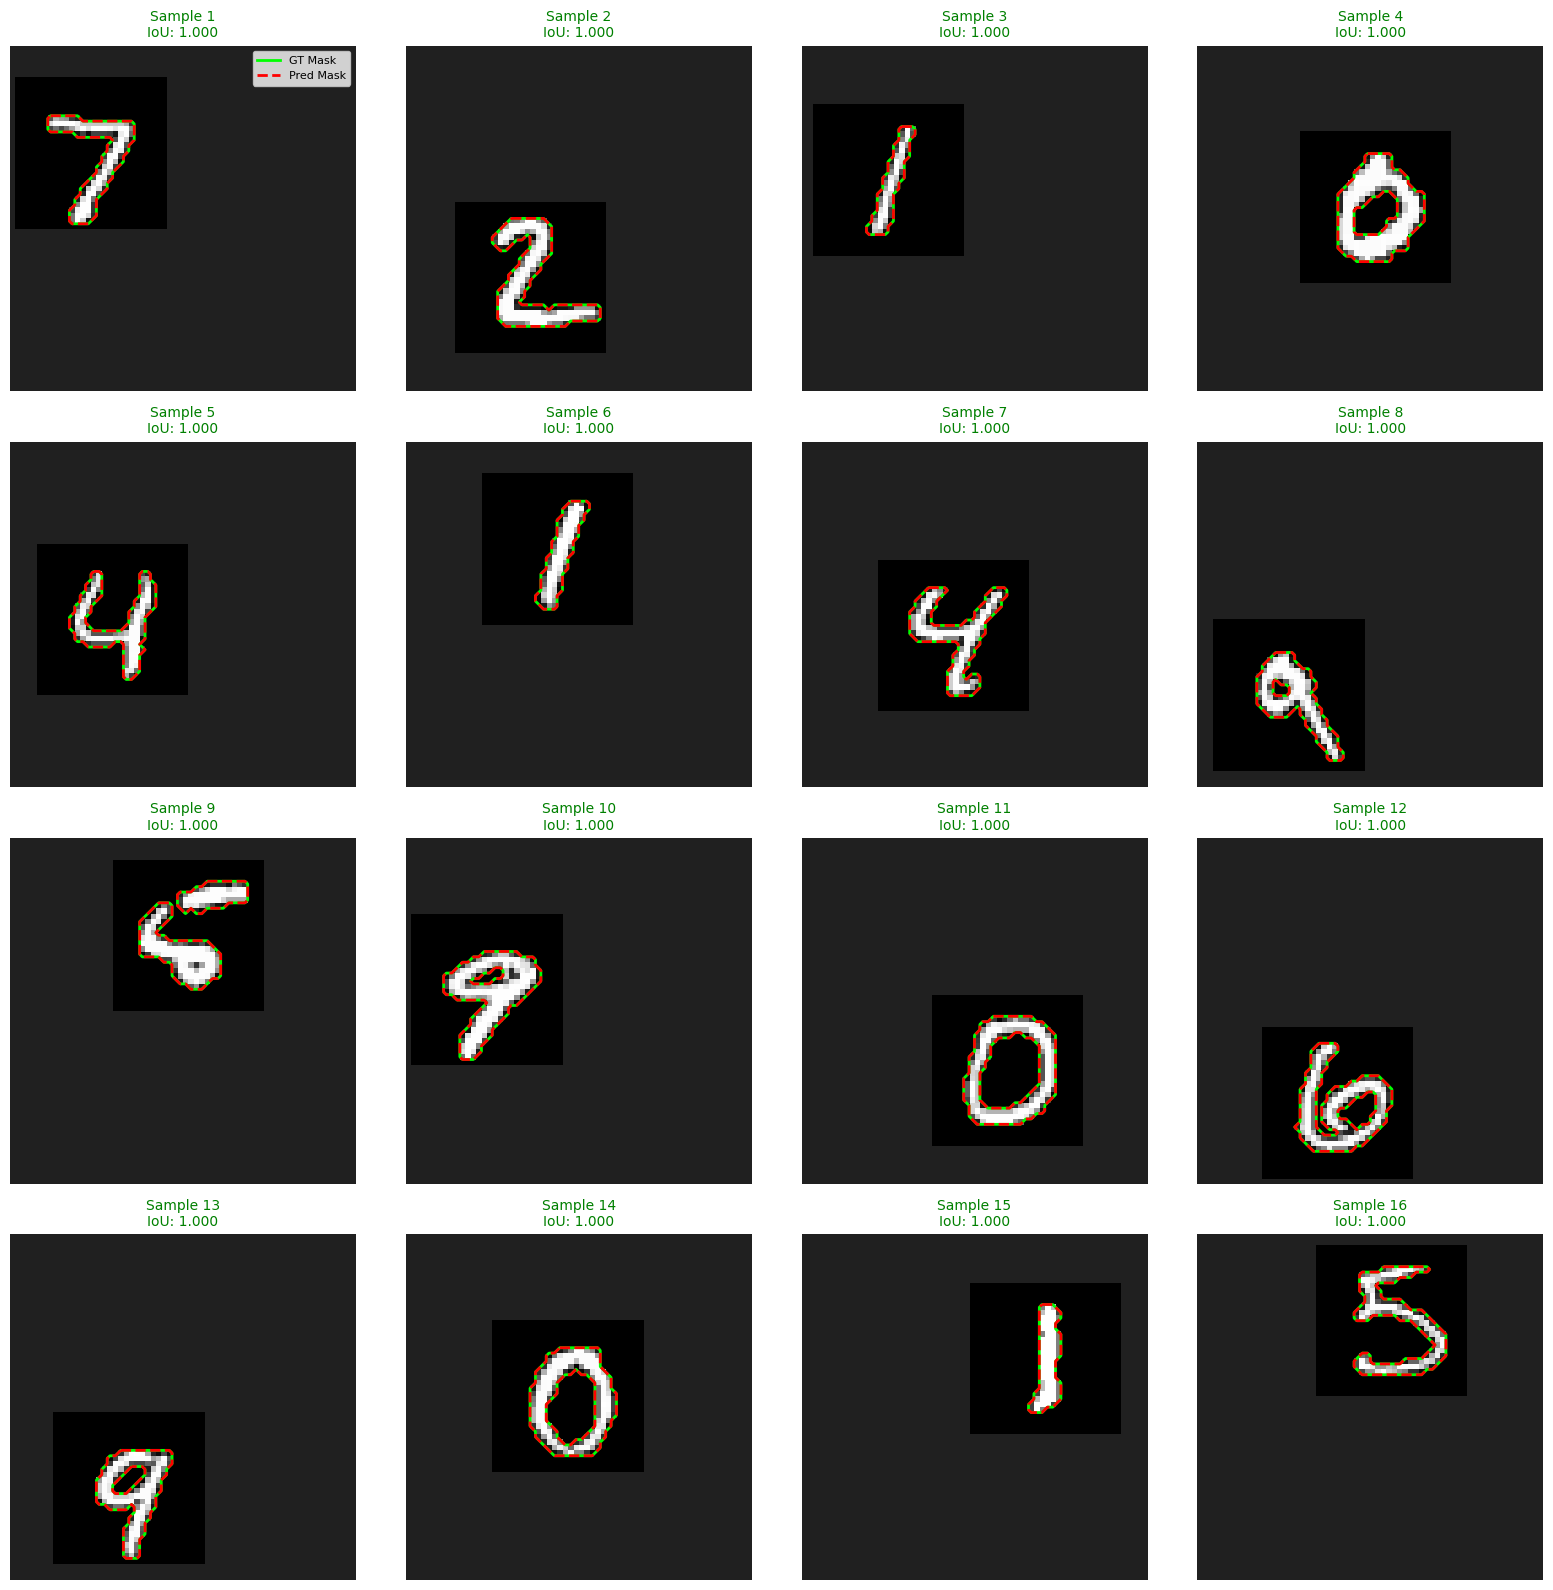

In [17]:
@torch.no_grad()
def evaluate_and_visualize_seg(model, data_loader, device, num_visualize=4):
    """
    对分割模型进行全面评估，输出 Loss、Pixel Accuracy、Mean IoU，并可视化预测结果。

    参数:
    - model: 训练好的 TinyUNet 分割模型
    - data_loader: 测试集的 DataLoader (seg_test_loader)
    - device: torch.device ('cuda' 或 'cpu')
    - num_visualize: 抽样可视化的图片数量（建议为 4 的倍数）
    """
    model.eval()

    total_loss = 0.0
    total_pixel_correct = 0
    total_pixel_count = 0
    total_iou = 0.0
    total_samples = 0

    criterion = nn.BCEWithLogitsLoss()   # 使用带 logits 的损失，内部自动 sigmoid

    # 用于保存第一个 batch 前 num_visualize 个样本的可视化数据
    vis_imgs, vis_masks, vis_preds = None, None, None

    for batch_idx, (imgs, masks) in enumerate(data_loader):
        imgs, masks = imgs.to(device), masks.to(device)

        # ---- 模型前向 ----
        outputs = model(imgs)                # (B, 1, H, W) 或 (B, num_classes, H, W)
        if outputs.shape[1] == 1:
            logits = outputs                 # 单通道输出，直接用于 BCEWithLogitsLoss
        else:
            # 多类别情况（如 num_classes=2），取前景通道作为二分类 logits
            logits = outputs[:, 1:2, :, :]   # 取类别 1 的 logits

        # ---- 1. 计算 Loss ----
        loss = criterion(logits, masks.float())   # masks 需为 float 且形状匹配
        total_loss += loss.item() * imgs.size(0)

        # ---- 2. 计算 Pixel Accuracy ----
        pred_prob = torch.sigmoid(logits)         # 转为概率
        pred_bin = (pred_prob > 0.5).float()
        correct = (pred_bin == masks).sum().item()
        total_pixel_correct += correct
        total_pixel_count += masks.numel()

        # ---- 3. 计算每个样本的 IoU (前景 IoU) ----
        # 将预测和真值展平为 B x N
        pred_flat = pred_bin.view(imgs.size(0), -1)
        target_flat = masks.view(imgs.size(0), -1).float()
        intersection = (pred_flat * target_flat).sum(dim=1)
        union = (pred_flat + target_flat).clamp(0, 1).sum(dim=1)
        iou_per_sample = (intersection + 1e-6) / (union + 1e-6)   # (B,)
        total_iou += iou_per_sample.sum().item()

        total_samples += imgs.size(0)

        # ---- 保存第一个 batch 用于可视化 ----
        if batch_idx == 0:
            vis_imgs = imgs[:num_visualize].cpu()
            vis_masks = masks[:num_visualize].cpu()
            vis_preds = pred_bin[:num_visualize].cpu()

    # ================== 打印统计指标 ==================
    avg_loss = total_loss / total_samples
    pixel_acc = (total_pixel_correct / total_pixel_count) * 100.0
    mean_iou = total_iou / total_samples

    print(f"Seg Loss:       {avg_loss:.4f}")
    print(f"Pixel Accuracy:   {pixel_acc:.2f}%")
    print(f"Mean IoU:       {mean_iou:.4f}")

    # ================== 可视化样例 ==================
    cols = 4
    rows = (num_visualize + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten() if num_visualize > 1 else [axes]

    for i in range(num_visualize):
        # 处理图像 (可能为单通道或三通道)
        img_tensor = vis_imgs[i]  # (C, H, W)
        if img_tensor.shape[0] == 1:
            img_np = img_tensor.squeeze().numpy()
        else:
            img_np = img_tensor.permute(1, 2, 0).numpy()
            if img_np.shape[2] == 3:
                img_np = img_np[:, :, 0]  # 取第一个通道作为灰度显示

        # mask 真值
        mask_np = vis_masks[i].squeeze().numpy()  # (H, W)
        # 预测二值 mask
        pred_np = vis_preds[i].squeeze().numpy()

        ax = axes[i]
        ax.imshow(img_np, cmap='gray')

        # 绘制真实 mask 轮廓 (绿色实线)
        ax.contour(mask_np, levels=[0.5], colors='lime', linewidths=2)
        # 绘制预测 mask 轮廓 (红色虚线)
        ax.contour(pred_np, levels=[0.5], colors='red', linewidths=2, linestyles='--')

        # 计算该样本的 IoU 用于标题展示
        inter = np.logical_and(pred_np > 0.5, mask_np > 0.5).sum()
        union = np.logical_or(pred_np > 0.5, mask_np > 0.5).sum()
        single_iou = inter / (union + 1e-6)

        ax.set_title(f"Sample {i+1}\nIoU: {single_iou:.3f}", fontsize=10,
                     color='green' if single_iou > 0.6 else 'red')
        ax.axis('off')

        # 在图例中仅第一张图显示说明
        if i == 0:
            from matplotlib.lines import Line2D
            custom_lines = [Line2D([0], [0], color='lime', lw=2),
                            Line2D([0], [0], color='red', lw=2, linestyle='--')]
            ax.legend(custom_lines, ['GT Mask', 'Pred Mask'], loc='upper right', fontsize=8)

    # 关闭多余的子图
    for j in range(num_visualize, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

model = TinyUNet(in_channels=1, num_classes=1).to(device)
model.load_state_dict(torch.load('unet_model.pth'))
evaluate_and_visualize_seg(model, seg_test_loader, device, num_visualize=16)

这个分割问题就是让网络学习怎区分黑色和白色，这么多参数只是为了实现 img > 0 这样一句话的功能。杀鸡用牛刀，准确率 100% 并不惊奇。

#### 2. ONNX 跨平台部署加速
任务要求：使用 torch.onnx.export 将训练好的 PyTorch 模型转换为 ONNX 格式。使用 ONNX Runtime 在 CPU 上进行推理，对比其与原生 PyTorch 推理的 每帧耗时（Latency）。 

使用 time 模块测量不同后端（PyTorch vs ONNX）的执行时间。 注意剔除“首帧冷启动时间”，取后续 50 次推理的平均值作为 Latency 结果。 


In [19]:
device = torch.device("cpu")
model = TinyUNet(in_channels=1, num_classes=1).to(device)
model.load_state_dict(torch.load('unet_model.pth'))
model.eval()
dummy_input = torch.randn(1, 1, 64, 64)   # 单通道灰度图
onnx_path = "tinyunet_seg.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    # 如果需要动态 batch，用 dynamic_shapes 代替：
    # dynamic_shapes={"input": {0: torch.export.Dim("batch", max=64)}, "output": {0: ...}},
    opset_version=18,            # 用 18，避免降级
    do_constant_folding=True,
)

print("ONNX 模型已保存至:", onnx_path)

[torch.onnx] Obtain model graph for `TinyUNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TinyUNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


d:\ProgramData\anaconda3\envs\yolo\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX 模型已保存至: tinyunet_seg.onnx


In [26]:
# ==================== 延迟测试函数 ====================
def pytorch_latency(model, inp, warmup=10, repeat=50):
    model.eval()
    with torch.no_grad():
        for _ in range(warmup): _ = model(inp)
    torch.cpu.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(repeat): _ = model(inp)
    torch.cpu.synchronize()
    t1 = time.perf_counter()
    return (t1 - t0) / repeat * 1000

def onnx_latency(sess, inp, warmup=10, repeat=50):
    iname = sess.get_inputs()[0].name
    for _ in range(warmup): sess.run(None, {iname: inp})
    t0 = time.perf_counter()
    for _ in range(repeat): sess.run(None, {iname: inp})
    t1 = time.perf_counter()
    return (t1 - t0) / repeat * 1000

测试时间

In [25]:
import onnxruntime as ort
device = torch.device("cpu")
model.to(device)
test_in = torch.randn(1, 1, 64, 64).to(device)

sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

lat_pt = pytorch_latency(model, test_in)
lat_onnx = onnx_latency(sess, test_in.numpy())

print(f"PyTorch Latency: {lat_pt:.4f} ms")
print(f"ONNX Runtime Latency: {lat_onnx:.4f} ms")
print(f"Speedup: {lat_pt / lat_onnx:.2f}x")

PyTorch Latency: 16.9158 ms
ONNX Runtime Latency: 195.2827 ms
Speedup: 0.09x


用 ONNX 简化之后反而比 pytorch 慢了，貌似是 CMRF 中的切片操作转为 ONNX 后会变成一串 Split → Slice → Concat → Add 的密集小算子序列。TinyUNet 模型看来不适合用 ONNX 运行。


## 五、实验结果与分析

本实验围绕“目标检测、语义分割与部署优化”三个层面展开，分别验证了轻量检测模型、YOLOv8 工程推理流程、Tiny U-Net 分割网络以及 ONNX Runtime 部署的实际效果。整体结果表明，在任务难度适中或较低的场景下，轻量模型能够取得较好的精度；但在部署阶段，推理后端的切换并不一定天然带来加速，仍需结合模型结构具体分析。

### 1. 自建数字检测模型的结果分析

在极简数字定位任务中，模型需要同时完成数字类别识别与边界框回归。训练过程中，整体 Loss 从 **1.2663** 逐步下降到 **0.0680**，Mean IoU 从 **0.9202** 提升到 **0.9824**，说明模型能够稳定学习数字的类别信息和位置信息，训练过程收敛良好。最终测试结果中，分类损失为 **0.0316**，边界框损失为 **0.0182**，分类准确率达到 **98.99%**，平均 IoU 达到 **0.9818**。这说明所设计的轻量 CNN 在该单目标、单类别实例的合成场景下已经能够较准确地完成检测任务。

从结果上看，训练前期 Loss 下降较快，IoU 上升明显，说明网络迅速学习到了数字轮廓与空间位置的基本特征；训练后期改进幅度逐渐减小，表明模型已趋于收敛。这一现象符合深度学习模型在简单任务中的常见规律。由于本实验中的输入图像背景固定、目标数量单一、目标形态规则，因此该任务整体难度相对有限，较高的 Accuracy 和 IoU 是合理的。但这也意味着模型的泛化能力主要体现在“合成数字定位”这一受控场景中，若换成更复杂背景、多目标遮挡或尺度变化明显的真实图像，性能仍可能下降。

### 2. YOLOv8 推理与 NMS 实验结果分析

在 YOLOv8 推理实验中，本实验重点考察了不同置信度阈值下检测框数量与检测质量之间的关系，并手动实现了 NMS 对重叠框进行筛除。实验结果显示，当置信度阈值分别取 **0.01、0.05、0.10** 时，原始冗余边界框数量分别为 **46、12、7**，经过 NMS 后保留的边界框数量分别减少为 **24、8、5**。这说明 NMS 能有效抑制大量重叠预测框，使最终检测结果更加紧凑、清晰。

进一步结合可视化结果分析可以发现：当置信度阈值过低时，模型虽然召回了较多候选目标，但误检也显著增加，例如把玩偶和手臂误识别为人、把书包误识别为电视等；当阈值提高后，错误框数量明显减少，检测结果更干净，但也会伴随一定漏检风险。实验中 `conf=0.10` 时总体效果相对较好，虽然仍存在把玩偶识别为人的现象，但大部分目标已经被较合理地识别出来。由此可见，**置信度阈值的选择本质上是在召回率与精确率之间进行平衡**，而 NMS 的作用主要是抑制重复框，并不能纠正模型本身的语义误判。

这一部分实验说明，目标检测的实际效果不仅由模型决定，还与后处理策略密切相关。模型输出的是大量候选框，而最终能否得到符合人类直觉的检测结果，很大程度上依赖于阈值和 NMS 的设置。因此，在真实工程中，检测系统的效果优化往往不是单纯“换更大模型”，而是需要将模型预测与后处理参数联合考虑。

### 3. Tiny U-Net 分割结果分析

在语义分割实验中，Tiny U-Net 需要将合成数字图像中的前景数字与黑色背景区分开来。训练结果显示，模型在第 1 个 epoch 时 Loss 已降至 **0.0201**，Train Pixel-IoU 达到 **0.9856**；到第 5 个 epoch 时，Loss 基本趋近于 **0**，Train Pixel-IoU 达到 **1.0000**。最终测试阶段，分割损失为 **0.0000**，像素准确率达到 **100.00%**，Mean IoU 为 **1.0000**。从数值上看，模型几乎实现了完美分割。

不过，这样的结果并不意味着 Tiny U-Net 在一般分割任务上都具备同样强的能力，更大的原因在于本实验数据本身较简单。输入图像主要由黑底和白色数字构成，前景背景对比极强，分割任务本质上接近于学习一个“是否为非黑色像素”的规则。因此，该实验更适合作为 U-Net 结构与像素级监督学习流程的演示，而不是对复杂语义分割能力的严格检验。换言之，本实验验证了网络在简单前景分割任务中的可行性，但并不能直接说明其在自然图像、多类别场景或复杂边界条件下同样有效。

### 4. ONNX 部署加速实验结果分析

在部署优化实验中，使用 `torch.onnx.export` 将训练好的 Tiny U-Net 导出为 ONNX 模型，并基于 ONNX Runtime 在 CPU 上进行推理。实验测得 PyTorch 平均推理延迟为 **16.9158 ms**，而 ONNX Runtime 平均推理延迟为 **195.2827 ms**，速度比仅为 **0.09x**。也就是说，在本实验设置下，ONNX 不但没有实现加速，反而明显慢于原生 PyTorch。

这一结果说明，**ONNX 并不总是意味着更快的推理速度**。影响部署速度的因素不仅包括模型大小，还包括网络结构、算子类型、后端优化程度以及硬件环境等。对本实验中的 Tiny U-Net 而言，模型本身规模较小，且内部包含较多切片、拼接等操作，这些操作在导出为 ONNX 后可能被拆解为多个细粒度小算子，导致 CPU 上的调度和算子调用开销增大，最终使 ONNX Runtime 性能劣于 PyTorch。由此可见，部署优化应以实际 profiling 结果为依据，而不能简单地认为“导出 ONNX 就一定更快”。

### 5. 综合分析

综合以上实验结果可以看出，本实验较完整地展示了从“模型训练”到“后处理优化”再到“推理部署”的完整流程。自建数字检测模型在简单受控场景下取得了较高的 Accuracy 和 IoU，说明分类与定位联合学习是可行的；YOLOv8 实验说明了 NMS 与置信度阈值对于检测质量的重要影响；Tiny U-Net 在简单二值分割任务中达到了极高精度，验证了其像素级学习能力；而 ONNX 部署实验则提醒我们，部署性能必须通过实测判断，不能仅凭经验推断。整体来看，本实验不仅验证了模型本身的可用性，也加深了对检测、分割和推理优化之间关系的理解。

## 六、问题与解决过程

### 1. 分割指标接近满分

在分割实验中，测试阶段得到 Pixel Accuracy 100% 和 Mean IoU 1.0000，看起来结果极其理想。但真正分析后发现，这一现象背后也存在“指标过于乐观”的问题。因为实验数据是合成的，背景几乎恒定为黑色，数字前景又十分清晰，模型只要学到简单的前景背景区分规则，就能取得很高分数。也就是说，这里的问题不是模型不够好，而是评价场景过于容易，导致指标无法充分反映模型在复杂场景中的真实能力。针对这个问题，我在结果分析中没有直接把“100% 准确率”解释为模型绝对优秀，而是把它理解为：在当前任务设定下，模型已经足以解决问题，但数据复杂度不高，结论不能被无限外推到真实复杂分割任务中。这一处理方式也使实验结论更加客观。

### 2. ONNX 部署本想加速，结果反而变慢

本实验中最出乎意料的问题出现在部署阶段。原本预期是将 PyTorch 模型导出为 ONNX 之后，ONNX Runtime 能在 CPU 上获得更快的推理速度；但实测结果却显示，ONNX Runtime 延迟远大于 PyTorch。刚开始我怀疑是导出过程有问题，或者测试代码计时不准确。后来我重新检查了模型导出、输入格式、运行环境以及推理计时流程，确认实验过程本身没有明显错误。最终结合模型结构进行分析后认为，问题更可能出在算子层面：Tiny U-Net 中的一些切片、拼接等操作在导出为 ONNX 后被拆分为大量细碎算子，增加了 CPU 执行时的调度开销，从而抵消甚至超过了理论上的后端优化收益。


## 七、思考题
### 1. 检测与分类的区别：在目标检测任务中，为什么单纯使用准确率（Accuracy）无法评估模型好坏？

答：目标检测属于**多物体、多类别且存在严重类别不平衡**的任务，准确率（Accuracy）的定义在这里会失效或产生误导。如果以“像素级准确率”评估分割型检测，背景像素通常占据图像的 90% 以上，模型即使完全不检出任何目标，仅靠预测全为背景就能获得 90%+ 的准确率，这显然不能反映检测前景物体的能力。如果以“图像级准确率”（整张图所有目标分类和定位完全正确才算对），则由于一张图可能包含多个目标，稍有漏检或定位偏差就判错，导致准确率极低且与模型实际性能不相关。目标检测通常使用 **平均精确度（AP）** 或 **mAP（mean AP）**，该指标综合考虑了：精确率和召回率。通过改变置信度阈值计算 PR 曲线下的面积，并且用 **IoU（交并比）** 判断检测框是否匹配真实框。因此，准确率因无法处理背景主导、多目标、定位精度等问题，不适用于目标检测评估。

### 2. 跳跃连接的作用：在 U‑Net 实验中，如果不使用 Skip Connection，生成的分割掩码（Mask）边缘会出现什么变化？

答：跳跃连接将编码器中高分辨率、富含空间细节的特征图直接传递给解码器，帮助解码器在上采样恢复分辨率时精确定位目标边界。如果不使用跳跃连接，解码器只能依赖编码器最后的低分辨率特征图（经过多次下采样，空间信息严重压缩），再通过连续的上采样恢复尺寸。这会导致：边缘变得模糊粗糙，小目标或狭长结构丢失，可能产生孔洞或断裂。

### 3. 推理加速：为什么 ONNX 格式在 CPU 上的推理速度通常比原生 PyTorch 框架快？

答：ONNX（Open Neural Network Exchange）是一种开放的模型表示格式，配合 **ONNX Runtime** 推理引擎。相比原生 PyTorch（以 eager mode 执行），ONNX Runtime 在 CPU 上的推理速度更快，主要原因如下：

1. **静态图优化**  
   - PyTorch 默认采用 **动态计算图（eager execution）**，每次前向传播都会重新构建图，存在 Python 解释器开销、算子分发的额外成本。  
   - ONNX 会将模型导出为 **静态图**，推理时直接执行已经优化过的计算流，消除了动态开销。

2. **图级融合与算子优化**  
   - ONNX Runtime 会对计算图进行扫描和重写，例如：将 `Conv + BatchNorm + ReLU` 融合成单个 kernel；将连续的 `Add` 或 `MatMul` 合并；消除冗余的 `Transpose` 操作。  
   - PyTorch 在 eager 模式下算子边界是固定的，难以跨算子做深度融合。

3. **针对 CPU 的高度优化的内核**  
   - ONNX Runtime 集成了 **Intel MKL‑DNN (oneDNN)**、**Eigen**、**OpenBLAS** 等后端，并对 x86 CPU 的 AVX2/AVX‑512 指令集进行了显式优化。  
   - 对于常见算子（卷积、全连接、池化等），ONNX Runtime 调用的实现比 PyTorch 默认的 CPU 内核更高效，且支持更激进的多线程调度。

4. **内存复用与更少的内存分配**  
   - 静态图中可以预先分析张量生命周期，实现内存池复用，减少动态内存分配和释放的次数。  
   - PyTorch 的 eager 模式中每个算子都会临时分配输出张量，带来额外开销。

5. **更轻量的运行时**  
   - ONNX Runtime 专门为推理设计，移除了训练相关的自动微分、梯度缓存、动态图构造等模块，运行时占用更少，执行路径更短。

**注意**：上述优势主要体现在 CPU 推理上；对于 GPU，PyTorch 通过 cuDNN 等也做了大量优化，速度差异可能缩小，但 ONNX Runtime 在 CPU 场景下优势明显。

## 八、实验小结

本次实验围绕目标检测、语义分割和推理部署三个方面展开，较系统地完成了从模型训练到工程推理再到后端优化的完整流程。通过自建数字定位模型，我理解了边界框回归、分类分支和 IoU/DIoU 指标之间的关系，并验证了轻量 CNN 在简单单目标检测任务上的有效性。通过 YOLOv8 推理与手写 NMS，我进一步认识到目标检测的最终效果不仅依赖模型本身，还与置信度阈值、非极大值抑制等后处理参数密切相关。

在语义分割部分，Tiny U-Net 在合成数字分割任务上取得了非常高的 Pixel Accuracy 和 Mean IoU，这说明 U-Net 结构能够有效完成像素级预测任务。不过实验也提醒我，高指标并不一定意味着模型在所有场景下都很强，有时也可能是因为任务本身较简单。因此，在分析实验结果时，需要把模型能力与数据复杂度放在一起考虑，避免对结论作过度推广。

在部署实验中，ONNX Runtime 的实际推理速度反而低于 PyTorch，这一结果让我对“部署优化”有了更现实的认识。模型部署不是简单地换一个推理后端就一定会更快，而是要看模型结构、算子类型与运行平台之间的匹配程度。只有通过真实测试和性能分析，才能得出可靠结论。

总体而言，本次实验不仅让我掌握了目标检测、语义分割和 ONNX 部署的基本流程，也让我更加清楚地认识到：深度学习实验不能只关注训练是否成功、loss 是否下降，更要重视测试指标、可视化结果与实际部署性能之间的统一。只有把“训练、评估、分析、部署”作为一个完整闭环来看，才能真正理解模型在实际应用中的表现。